In [2]:
import subprocess
subprocess.run(['py', '-m', 'pip', 'install', 'scipy'])
print("Scipy installed!")

Scipy installed!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("All libraries imported!")

All libraries imported!


In [4]:
df = pd.read_csv(r'C:\Users\Admin\OneDrive\Desktop\Applex\cleaned_ecommerce_data.csv')
print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (1000, 23)


,Order_ID,Customer_ID,Customer_Name,Category,Sub_Category,Product_Name,Order_Date,Ship_Date,Region,City,...,Profit,Payment_Mode,Customer_Age,Rating,Order_Year,Order_Month,Order_Month_Name,Delivery_Days,Profit_Margin,Age_Group
0,ORD0001,CUST103,Vijay,Sports,Shirt,Mixer,2023-01-01 00:00:00,2023-01-03 00:00:00,North,Hyderabad,...,477.63,Net Banking,41.0,1.0,2023,1,January,2,18.69,Adult
1,ORD0002,CUST180,Deepa,Books,Shirt,Samsung TV,2023-01-01 08:00:00,2023-01-03 08:00:00,East,Mumbai,...,4415.49,COD,26.0,1.0,2023,1,January,2,37.96,Young Adult
2,ORD0003,CUST093,Sneha,Sports,Mobile,Python Book,2023-01-01 16:00:00,2023-01-03 16:00:00,North,Chennai,...,8819.19,UPI,32.0,4.0,2023,1,January,2,19.65,Young Adult
3,ORD0004,CUST015,Priya,Clothing,Novel,iPhone 14,2023-01-02 00:00:00,2023-01-04 00:00:00,North,Hyderabad,...,6233.29,Net Banking,52.0,5.0,2023,1,January,2,48.38,Senior
4,ORD0005,CUST107,Anita,Electronics,Shoes,Samsung TV,2023-01-02 08:00:00,2023-01-04 08:00:00,North,Delhi,...,3843.27,UPI,41.0,4.0,2023,1,January,2,34.59,Adult


In [5]:
print("=" * 50)
print("DATA STORY: E-COMMERCE SALES ANALYSIS")
print("=" * 50)
print("\nObjective:")
print("Analyze sales patterns to identify key")
print("business opportunities and challenges")
print("\nKey Questions:")
print("1. Which region performs best?")
print("2. Which category is most profitable?")
print("3. Does discount affect profit?")
print("4. Which payment mode is most popular?")
print("5. Who are our best customers?")
print("=" * 50)

DATA STORY: E-COMMERCE SALES ANALYSIS

Objective:
Analyze sales patterns to identify key
business opportunities and challenges

Key Questions:
1. Which region performs best?
2. Which category is most profitable?
3. Does discount affect profit?
4. Which payment mode is most popular?
5. Who are our best customers?


In [6]:
print("=" * 50)
print("KEY FINDINGS")
print("=" * 50)

# Finding 1 - Best Region
best_region = df.groupby('Region')['Sales'].sum().idxmax()
best_region_sales = df.groupby('Region')['Sales'].sum().max()
print(f"\n1. Best Region: {best_region}")
print(f"   Total Sales: Rs.{best_region_sales:,.2f}")

# Finding 2 - Best Category
best_cat = df.groupby('Category')['Profit'].sum().idxmax()
best_cat_profit = df.groupby('Category')['Profit'].sum().max()
print(f"\n2. Most Profitable Category: {best_cat}")
print(f"   Total Profit: Rs.{best_cat_profit:,.2f}")

# Finding 3 - Best Payment Mode
best_payment = df.groupby('Payment_Mode')['Sales'].sum().idxmax()
print(f"\n3. Most Popular Payment Mode: {best_payment}")

# Finding 4 - Average Rating
avg_rating = df['Rating'].mean().round(2)
print(f"\n4. Average Customer Rating: {avg_rating}/5")

# Finding 5 - Best Month
best_month = df.groupby('Order_Month_Name')['Sales'].sum().idxmax()
print(f"\n5. Best Sales Month: {best_month}")

KEY FINDINGS

1. Best Region: West
   Total Sales: Rs.6,786,930.67

2. Most Profitable Category: Home & Kitchen
   Total Profit: Rs.1,096,791.35

3. Most Popular Payment Mode: UPI

4. Average Customer Rating: 3.03/5

5. Best Sales Month: January


In [7]:
print("=" * 50)
print("HYPOTHESIS TEST 1")
print("=" * 50)
print("H0: No significant difference in sales")
print("    between North and South regions")
print("H1: There IS a significant difference")
print("=" * 50)

north = df[df['Region'] == 'North']['Sales']
south = df[df['Region'] == 'South']['Sales']

t_stat, p_value = stats.ttest_ind(north, south)

print(f"\nNorth Avg Sales: Rs.{north.mean():,.2f}")
print(f"South Avg Sales: Rs.{south.mean():,.2f}")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < 0.05:
    print("\nResult: SIGNIFICANT DIFFERENCE FOUND!")
    print("North and South sales ARE different")
else:
    print("\nResult: NO SIGNIFICANT DIFFERENCE")
    print("North and South sales are similar")
print("=" * 50)

HYPOTHESIS TEST 1
H0: No significant difference in sales
    between North and South regions
H1: There IS a significant difference

North Avg Sales: Rs.25,247.63
South Avg Sales: Rs.26,133.21

T-statistic: -0.6771
P-value:     0.4987

Result: NO SIGNIFICANT DIFFERENCE
North and South sales are similar


In [10]:
print("HYPOTHESIS TEST 2")
print("H0: Discount has no effect on profit")
print("H1: Discount significantly affects profit")

no_discount = df[df['Discount'] == 0]['Profit']
with_discount = df[df['Discount'] > 0]['Profit']

t_stat, p_value = stats.ttest_ind(no_discount, with_discount)

print(f"Avg Profit without Discount: Rs.{no_discount.mean():,.2f}")
print(f"Avg Profit with Discount: Rs.{with_discount.mean():,.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: DISCOUNT SIGNIFICANTLY AFFECTS PROFIT!")
else:
    print("Result: DISCOUNT HAS NO SIGNIFICANT EFFECT")

HYPOTHESIS TEST 2
H0: Discount has no effect on profit
H1: Discount significantly affects profit
Avg Profit without Discount: Rs.4,983.17
Avg Profit with Discount: Rs.4,836.75
T-statistic: 0.6727
P-value: 0.5013
Result: DISCOUNT HAS NO SIGNIFICANT EFFECT


In [11]:
confidence = 0.95
n = len(df['Sales'])
mean = df['Sales'].mean()
se = stats.sem(df['Sales'])
ci = stats.t.interval(confidence, df=n-1, loc=mean, scale=se)

print("=" * 50)
print("CONFIDENCE INTERVAL")
print("=" * 50)
print(f"Mean Sales: Rs.{mean:,.2f}")
print(f"95% Confidence Interval:")
print(f"Lower: Rs.{ci[0]:,.2f}")
print(f"Upper: Rs.{ci[1]:,.2f}")
print("=" * 50)

CONFIDENCE INTERVAL
Mean Sales: Rs.24,877.97
95% Confidence Interval:
Lower: Rs.23,987.41
Upper: Rs.25,768.53


In [12]:
print("=" * 50)
print("A/B TEST")
print("=" * 50)
print("Testing: UPI vs Credit Card sales")
print("=" * 50)

upi = df[df['Payment_Mode'] == 'UPI']['Sales']
credit = df[df['Payment_Mode'] == 'Credit Card']['Sales']

t_stat, p_value = stats.ttest_ind(upi, credit)

print(f"UPI Avg Sales:         Rs.{upi.mean():,.2f}")
print(f"Credit Card Avg Sales: Rs.{credit.mean():,.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < 0.05:
    print("Result: SIGNIFICANT DIFFERENCE FOUND!")
else:
    print("Result: NO SIGNIFICANT DIFFERENCE")
print("=" * 50)

A/B TEST
Testing: UPI vs Credit Card sales
UPI Avg Sales:         Rs.26,165.11
Credit Card Avg Sales: Rs.25,319.14
T-statistic: 0.6660
P-value:     0.5057
Result: NO SIGNIFICANT DIFFERENCE


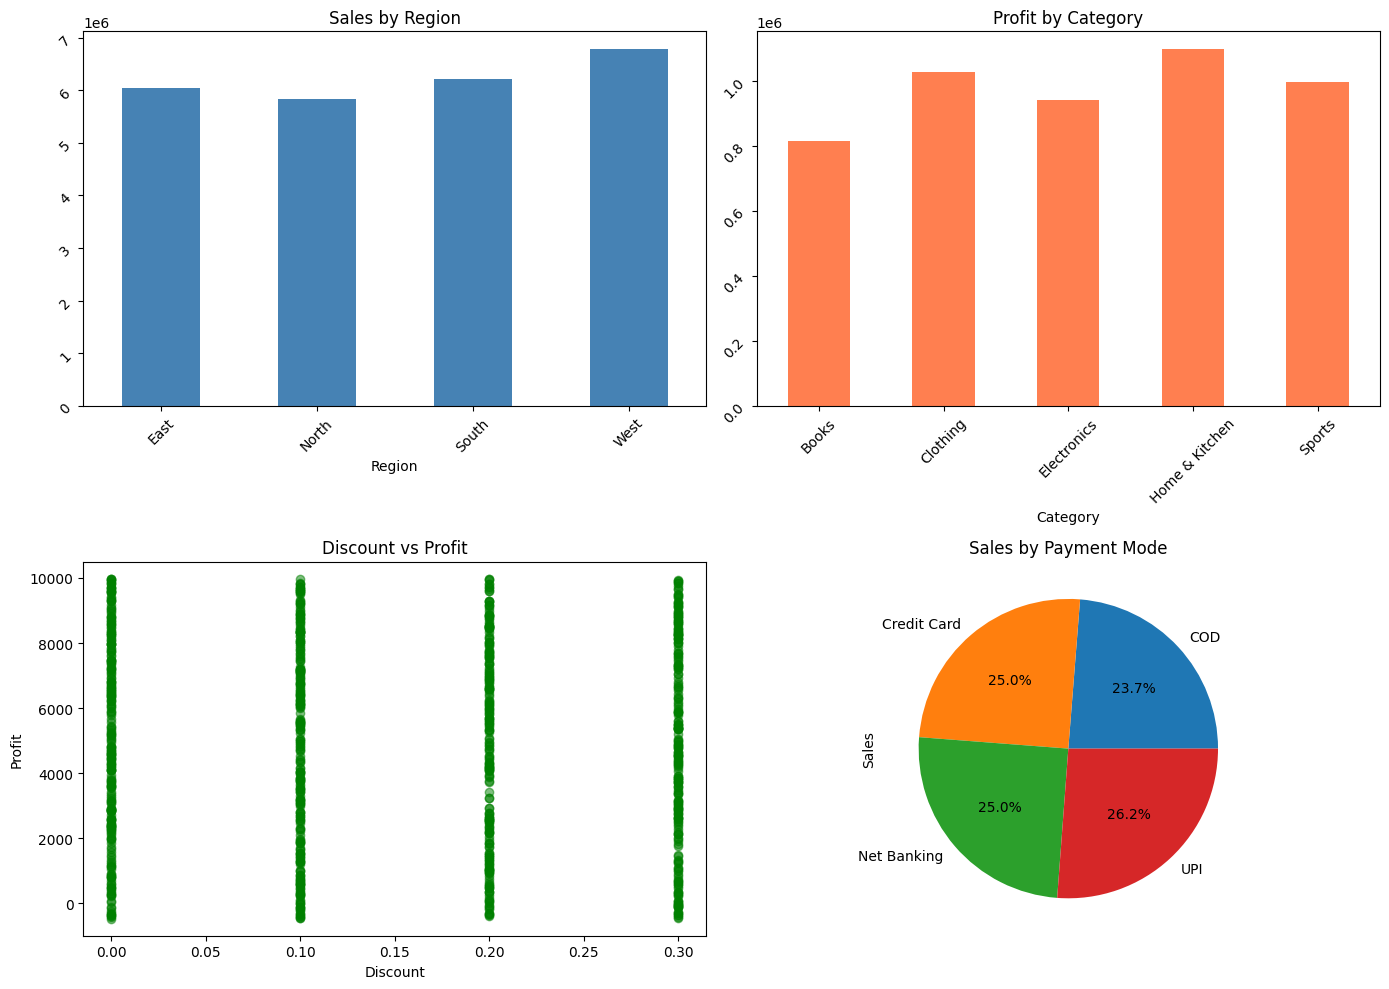

Story charts saved!


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - Sales by Region
df.groupby('Region')['Sales'].sum().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Sales by Region')
axes[0,0].tick_params(rotation=45)

# Chart 2 - Profit by Category
df.groupby('Category')['Profit'].sum().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Profit by Category')
axes[0,1].tick_params(rotation=45)

# Chart 3 - Discount vs Profit
axes[1,0].scatter(df['Discount'], df['Profit'], alpha=0.5, color='green')
axes[1,0].set_title('Discount vs Profit')
axes[1,0].set_xlabel('Discount')
axes[1,0].set_ylabel('Profit')

# Chart 4 - Sales by Payment Mode
df.groupby('Payment_Mode')['Sales'].sum().plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%')
axes[1,1].set_title('Sales by Payment Mode')

plt.tight_layout()
plt.savefig('task4_story_charts.png')
plt.show()
print("Story charts saved!")

In [14]:
print("=" * 50)
print("BUSINESS RECOMMENDATIONS")
print("=" * 50)

best_region = df.groupby('Region')['Sales'].sum().idxmax()
best_cat = df.groupby('Category')['Profit'].sum().idxmax()
best_payment = df.groupby('Payment_Mode')['Sales'].sum().idxmax()
best_month = df.groupby('Order_Month_Name')['Sales'].sum().idxmax()

print(f"\n1. Focus marketing on {best_region} region")
print(f"   as it generates highest sales")
print(f"\n2. Expand {best_cat} product line")
print(f"   as it generates highest profit")
print(f"\n3. Promote {best_payment} payment mode")
print(f"   as it is most popular among customers")
print(f"\n4. Increase inventory in {best_month}")
print(f"   as it is the best sales month")
print(f"\n5. Reduce heavy discounts as they")
print(f"   negatively impact profit margins")
print("=" * 50)

BUSINESS RECOMMENDATIONS

1. Focus marketing on West region
   as it generates highest sales

2. Expand Home & Kitchen product line
   as it generates highest profit

3. Promote UPI payment mode
   as it is most popular among customers

4. Increase inventory in January
   as it is the best sales month

5. Reduce heavy discounts as they
   negatively impact profit margins


In [16]:
print("=" * 50)
print("TASK 4 COMPLETE!")
print("=" * 50)
print("Completed:")
print("  - Data Story Created")
print("  - Key Findings Identified")
print("  - Hypothesis Test 1 Done")
print("  - Hypothesis Test 2 Done")
print("  - Confidence Interval Calculated")
print("  - A/B Test Completed")
print("  - Visualizations Created")
print("  - Business Recommendations Made")
print("\nFiles saved:")
print("  - task4_storytelling.ipynb")
print("  - task4_story_charts.png")
print("=" * 50)

TASK 4 COMPLETE!
Completed:
  - Data Story Created
  - Key Findings Identified
  - Hypothesis Test 1 Done
  - Hypothesis Test 2 Done
  - Confidence Interval Calculated
  - A/B Test Completed
  - Visualizations Created
  - Business Recommendations Made

Files saved:
  - task4_storytelling.ipynb
  - task4_story_charts.png
